# project 3
# Supply Chain GHG Emission Analysis by NAICS Sector

This notebook analyzes the U.S. supply-chain greenhouse gas emission factors (v1.3) released via Data.gov.  
The goal is to identify which industries exhibit the highest carbon intensity and compare emission patterns across major NAICS sectors.

**Dataset(s) to be used:**  
https://catalog.data.gov/dataset/supply-chain-greenhouse-gas-emission-factors-v1-3-by-naics-6

**Analysis question:**  
Which NAICS industries have the highest supply-chain carbon intensity, and how do emission patterns differ across major sectors such as agriculture, manufacturing, and services?

**Columns that will (likely) be used:**
- 2017 NAICS Code  
- 2017 NAICS Title  
- Supply Chain Emission Factors without Margins  
- Margins of Supply Chain Emission Factors  
- Supply Chain Emission Factors with Margins  

**Hypothesis:**  
Industries related to agriculture and heavy manufacturing will show significantly higher carbon intensity than service-oriented industries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("SupplyChainGHGEmissionFactors_v1.3.0_NAICS_CO2e_USD2022.csv")
df.head()

,2017 NAICS Code,2017 NAICS Title,GHG,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,Reference USEEIO Code
0,111110,Soybean Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.488,0.044,0.532,1111A0
1,111120,Oilseed (except Soybean) Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.488,0.044,0.532,1111A0
2,111130,Dry Pea and Bean Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
3,111140,Wheat Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
4,111150,Corn Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0


In [3]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 8 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   2017 NAICS Code                                1016 non-null   int64  
 1   2017 NAICS Title                               1016 non-null   object 
 2   GHG                                            1016 non-null   object 
 3   Unit                                           1016 non-null   object 
 4   Supply Chain Emission Factors without Margins  1016 non-null   float64
 5   Margins of Supply Chain Emission Factors       1016 non-null   float64
 6   Supply Chain Emission Factors with Margins     1016 non-null   float64
 7   Reference USEEIO Code                          1016 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 63.6+ KB


2017 NAICS Code                                  0
2017 NAICS Title                                 0
GHG                                              0
Unit                                             0
Supply Chain Emission Factors without Margins    0
Margins of Supply Chain Emission Factors         0
Supply Chain Emission Factors with Margins       0
Reference USEEIO Code                            0
dtype: int64

## Data Cleaning
The dataset is already clean, but we will standardize column names and create industry-level groupings using NAICS 2-digit codes.

In [4]:
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
)

df["naics_2digit"] = df["2017_naics_code"].astype(str).str[:2]
df.head()

,2017_naics_code,2017_naics_title,ghg,unit,supply_chain_emission_factors_without_margins,margins_of_supply_chain_emission_factors,supply_chain_emission_factors_with_margins,reference_useeio_code,naics_2digit
0,111110,Soybean Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.488,0.044,0.532,1111A0,11
1,111120,Oilseed (except Soybean) Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.488,0.044,0.532,1111A0,11
2,111130,Dry Pea and Bean Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0,11
3,111140,Wheat Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0,11
4,111150,Corn Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0,11


## Exploratory Data Analysis
Here we explore the distribution of emission factors across industries.

In [5]:
df_sorted = df.sort_values(
    by="supply_chain_emission_factors_with_margins", 
    ascending=False
)

df_sorted.head(10)

,2017_naics_code,2017_naics_title,ghg,unit,supply_chain_emission_factors_without_margins,margins_of_supply_chain_emission_factors,supply_chain_emission_factors_with_margins,reference_useeio_code,naics_2digit
285,327310,Cement Manufacturing,All GHGs,"kg CO2e/2022 USD, purchaser price",3.846,0.078,3.924,327310,32
33,112130,Dual-Purpose Cattle Ranching and Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",2.847,0.045,2.893,1121A0,11
31,112112,Cattle Feedlots,All GHGs,"kg CO2e/2022 USD, purchaser price",2.847,0.045,2.893,1121A0,11
30,112111,Beef Cattle Ranching and Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",2.847,0.045,2.893,1121A0,11
32,112120,Dairy Cattle and Milk Production,All GHGs,"kg CO2e/2022 USD, purchaser price",1.682,0.042,1.724,112120,11
290,327410,Lime Manufacturing,All GHGs,"kg CO2e/2022 USD, purchaser price",1.560,0.063,1.623,327400,32
291,327420,Gypsum Product Manufacturing,All GHGs,"kg CO2e/2022 USD, purchaser price",1.560,0.063,1.623,327400,32
655,486910,Pipeline Transportation of Refined Petroleum P...,All GHGs,"kg CO2e/2022 USD, purchaser price",1.619,0.000,1.619,486000,48
653,486110,Pipeline Transportation of Crude Oil,All GHGs,"kg CO2e/2022 USD, purchaser price",1.619,0.000,1.619,486000,48
654,486210,Pipeline Transportation of Natural Gas,All GHGs,"kg CO2e/2022 USD, purchaser price",1.619,0.000,1.619,486000,48


In [6]:
sector_avg = (
    df.groupby("naics_2digit")["supply_chain_emission_factors_with_margins"]
      .mean()
      .sort_values(ascending=False)
)

sector_avg.head()

naics_2digit
11    0.726625
22    0.566500
48    0.558240
32    0.531330
21    0.432321
Name: supply_chain_emission_factors_with_margins, dtype: float64

## Visualization
We visualize the average carbon intensity by NAICS sector (2-digit level).

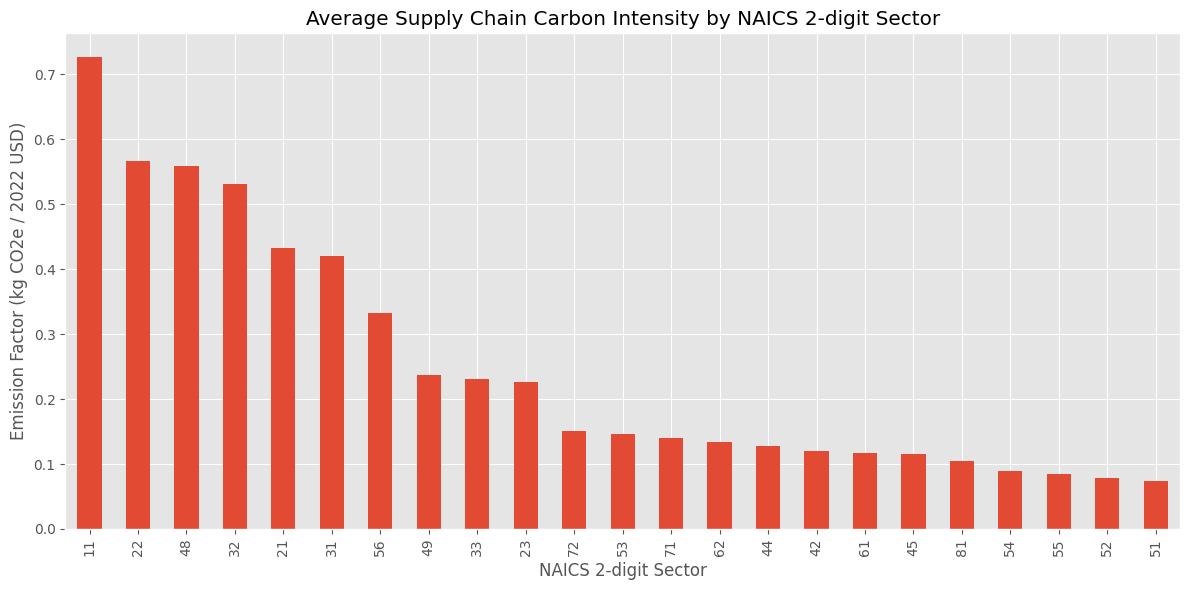

In [7]:
plt.figure(figsize=(12,6))
sector_avg.plot(kind="bar")
plt.title("Average Supply Chain Carbon Intensity by NAICS 2-digit Sector")
plt.xlabel("NAICS 2-digit Sector")
plt.ylabel("Emission Factor (kg CO2e / 2022 USD)")
plt.tight_layout()
plt.show()

# Conclusion

The analysis identifies which sectors have the highest supply-chain carbon intensity.  
As hypothesized, agriculture and manufacturing sectors exhibit significantly higher emission factors,  
while service-oriented industries show much lower intensities.  